# 🔩 Classification de Défauts de Surface — NEU Surface Defect Database

**Auteur :** *HACHEMI Dyhia*  
**Module :** Deep Learning — Contrôle Qualité par Vision Artificielle  
**Date :** Avril 2026  

---

## 🎯 Objectif du projet

Ce projet applique le Deep Learning à un problème réel de **contrôle qualité industriel** :
détecter et classifier automatiquement les défauts de surface sur des aciers laminés à chaud.

Nous allons comparer **deux approches** :
- **Approche A** — CNN entraîné from scratch
- **Approche B** — Transfer Learning avec MobileNetV2 (pré-entraîné sur ImageNet)

---

## 📂 Dataset : NEU Surface Defect Database

Le dataset contient **1440  images** (200×200 px, niveaux de gris) réparties en **6 classes** :

| Classe | Description |
|--------|-------------|
| `crazing` | Craquelures en réseau |
| `inclusion` | Impuretés incrustées |
| `patches` | Taches irrégulières |
| `pitted_surface` | Piqûres de surface |
| `rolled-in_scale` | Écailles laminées |
| `scratches` | Rayures linéaires |

> **Source :** [Kaggle — NEU Surface Defect Database](https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database)

---

## 🗂️ Structure du notebook

1. **Installation & Imports** — Mise en place de l'environnement
2. **Téléchargement du Dataset** — Via l'API Kaggle
3. **Exploration des Données (EDA)** — Distribution, visualisation des images
4. **Préparation des Données** — Générateurs avec augmentation
5. *(Jour 2)* **Modèles** — CNN Custom + Transfer Learning MobileNetV2
6. *(Jour 3)* **Évaluation** — Courbes, matrices de confusion, comparatif
7. *(Jour 3)* **Démo Gradio** — Interface de prédiction interactive


## Section 1 — Installation & Imports

In [1]:
# Installation des bibliothèques nécessaires
!pip install gradio kaggle opendatasets tensorflow matplotlib seaborn scikit-learn --quiet
print("Bibliothèques installées avec succès !")

Bibliothèques installées avec succès !


In [2]:
import os # Bibliotheque pour le Système & fichiers
# Bibliotheques pour la Visualisation
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
import numpy as np # Bibliotheque pour la Manipulation de données
import opendatasets as od # Bibliotheque pour le Téléchargement du dataset
# Bibliotheques pour le deep learning
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
# Bibliotheque pour l'évaluation
from sklearn.metrics import classification_report, confusion_matrix
# Vérification du GPU
print("TensorFlow version :", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU disponible : {gpus[0].name}")
else:
    print("Aucun GPU détecté — l'entraînement sera plus lent (CPU)")

TensorFlow version : 2.19.0
GPU disponible : /physical_device:GPU:0


## Section 2 — Téléchargement du Dataset


In [3]:
# Téléchargement du dataset NEU depuis Kaggle
print("Téléchargement du dataset...")
NEU_dataset = od.download("https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database")
print("Dataset téléchargé !")

# Afficher la structure du dossier racine
print("\nContenu du dossier téléchargé :")
print(os.listdir("neu-surface-defect-database"))

Téléchargement du dataset...
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: dyhiahachemi
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database


100%|██████████| 26.4M/26.4M [00:00<00:00, 128MB/s]



Dataset téléchargé !

Contenu du dossier téléchargé :
['NEU-DET']


In [4]:
# Vérification des 6 classes disponibles dans le jeu d'entraînement
TRAIN_PATH = "neu-surface-defect-database/NEU-DET/train/images"
VAL_PATH   = "neu-surface-defect-database/NEU-DET/validation/images"

classes = sorted(os.listdir(TRAIN_PATH))
print(f"Nombre de classes : {len(classes)}")
print(f"Classes : {classes}")

Nombre de classes : 6
Classes : ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


# Section 3 — Explorer les données (EDA)
### Compter le nombre d'images dans chaque classe

In [5]:
print(f"Distribution des images — Jeu d'entraînement\n")

nombres_images = []
for classe in classes:
    class_path = os.path.join(TRAIN_PATH, classe)
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    n = len(images)
    nombres_images.append(n)
    print(f"  {classe:<20} : {n} images")

print(f"\nTotal : {sum(nombres_images)} images | Moyenne : {sum(nombres_images)/len(nombres_images):.0f} images/classe")

Distribution des images — Jeu d'entraînement

  crazing              : 240 images
  inclusion            : 240 images
  patches              : 240 images
  pitted_surface       : 240 images
  rolled-in_scale      : 240 images
  scratches            : 240 images

Total : 1440 images | Moyenne : 240 images/classe


### Afficher la distribution des classes sous forme de graphique en barres

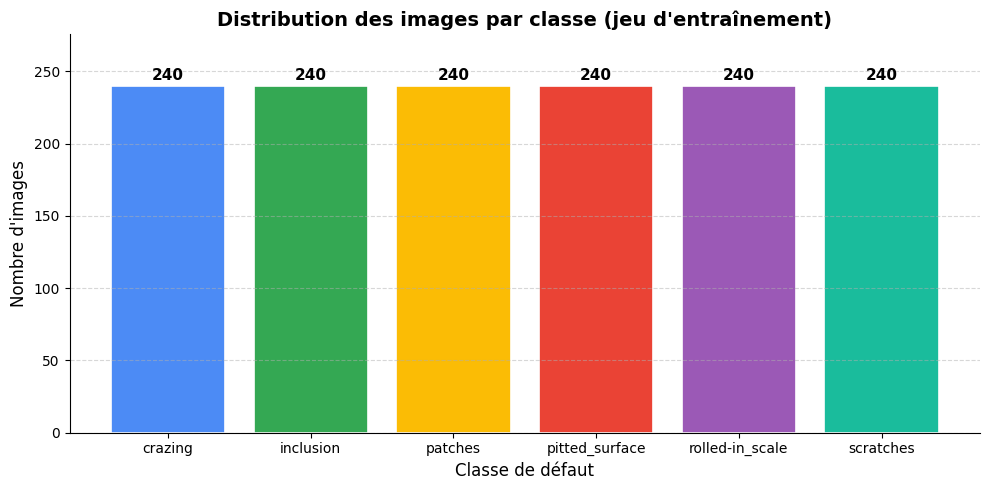

Dataset parfaitement équilibré : 240 images par classe.


In [6]:
# ── Graphique de distribution ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#4C8BF5', '#34A853', '#FBBC05', '#EA4335', '#9B59B6', '#1ABC9C']
bars = ax.bar(classes, nombres_images, color=colors, edgecolor='white', linewidth=1.2)

# Étiquettes numériques au-dessus de chaque barre
for bar, n in zip(bars, nombres_images):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2, str(n),
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xlabel('Classe de défaut', fontsize=12)
ax.set_ylabel("Nombre d'images", fontsize=12)
ax.set_title('Distribution des images par classe (jeu d\'entraînement)', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(nombres_images) * 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()

plt.tight_layout()
plt.show()

print("Dataset parfaitement équilibré : 240 images par classe.")

### 🖼️ Affichage de quelques exemples d'images pour chaque classe

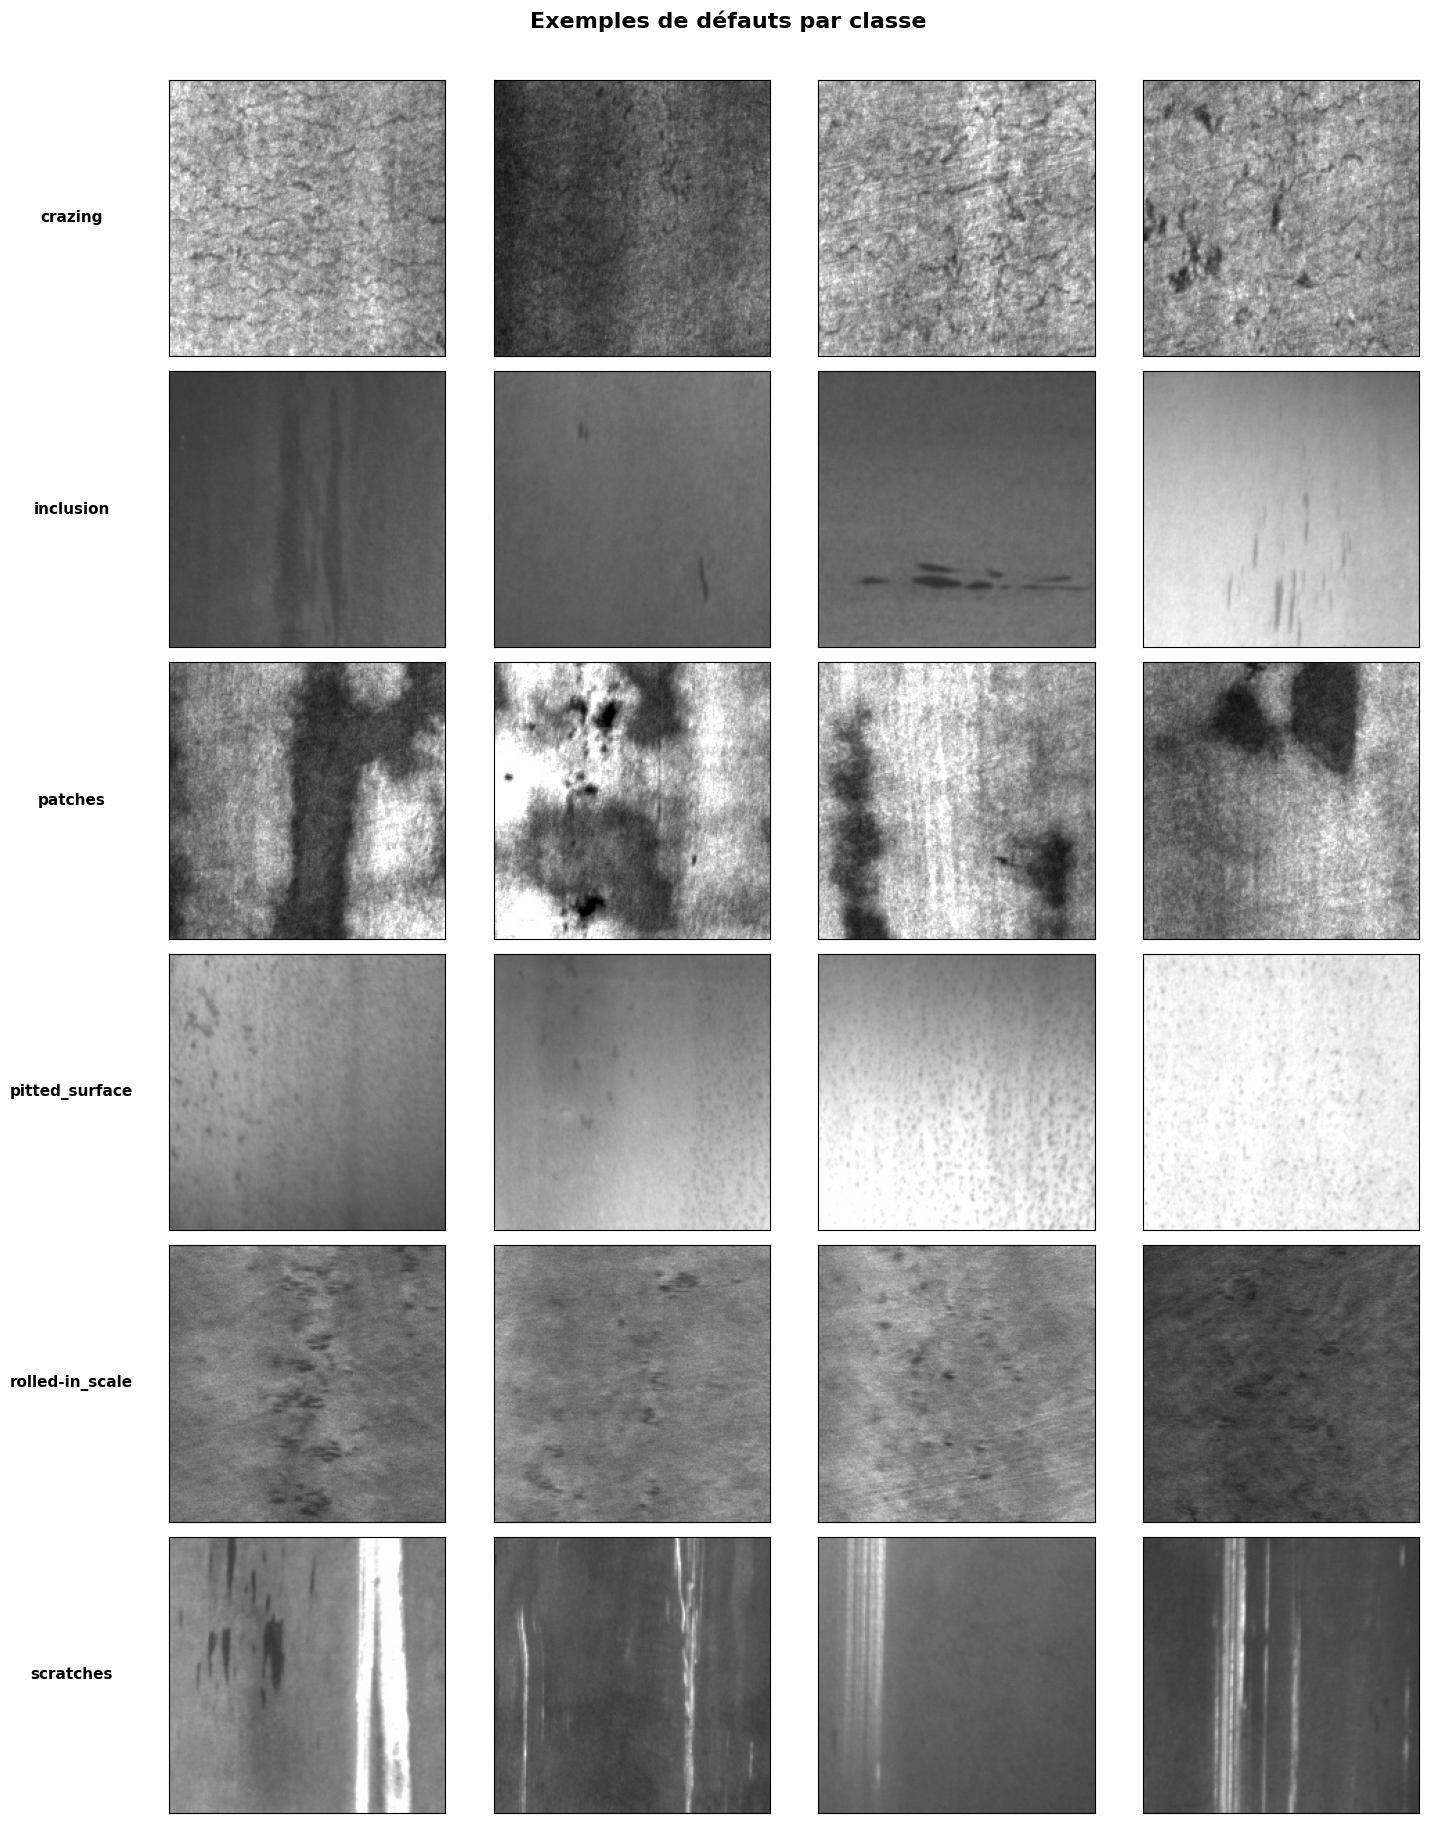

In [7]:
# ── Grille d'exemples : 4 images × 6 classes ─────────────────────────────────
N_SAMPLES = 4  # Nombre d'images à afficher par classe

fig, axes = plt.subplots(len(classes), N_SAMPLES,
                         figsize=(15, 3 * len(classes)))
fig.suptitle("Exemples de défauts par classe", fontsize=16, fontweight='bold', y=1.01)

for i, cls in enumerate(classes):
    folder_path = os.path.join(TRAIN_PATH, cls)
    img_names = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ][:N_SAMPLES]

    for j in range(N_SAMPLES):
        ax = axes[i, j]
        if j < len(img_names):
            img = Image.open(os.path.join(folder_path, img_names[j]))
            ax.imshow(img, cmap='gray')
            if j == 0:
                ax.set_ylabel(cls, fontsize=11, fontweight='bold',
                              rotation=0, labelpad=70, va='center')
        else:
            ax.axis('off')
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

## 🔄 Section 4 — Préparation des Données

On utilise `ImageDataGenerator` de Keras pour :
1. **Normaliser** les pixels (valeurs ramenées dans [0, 1])
2. **Augmenter** les données d'entraînement (rotations, décalages, flip…)

> ⚠️ L'augmentation est appliquée **uniquement au jeu d'entraînement**.
> Le jeu de validation reçoit uniquement la normalisation.

In [8]:
# Hyperparamètres des générateurs
IMG_SIZE   = (224, 224)   # Taille cible des images
BATCH_SIZE = 32           # Nombre d'images traitées à chaque itération
NB_CLASSES = 6            # Nombre de classes à prédire

# Générateur d'entraînement (avec augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# Générateur de validation (normalisation uniquement)
val_datagen = ImageDataGenerator(rescale=1./255)

# Chargement des images depuis les dossiers
train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'   # One-hot encoding pour classification multi-classes
)

val_generator = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Vérification
images_batch, labels_batch = next(train_generator)
print(f"Shape d'un batch d'images : {images_batch.shape}")
print(f"Shape des labels          : {labels_batch.shape}")
print(f"Correspondance classes    : {train_generator.class_indices}")

Found 1440 images belonging to 6 classes.
Found 360 images belonging to 6 classes.
Shape d'un batch d'images : (32, 224, 224, 3)
Shape des labels          : (32, 6)
Correspondance classes    : {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


---
## 🧠 Section 5 — Approche A : CNN Custom (from scratch)

On construit un CNN composé de blocs Conv2D + MaxPooling, suivi de couches Dense pour la classification finale.
Ce modèle servira de **baseline** pour comparer avec le Transfer Learning.

**Architecture :**
```
Entrée (224×224×3)
  │
  ├─ Bloc 1 : Conv2D(32)  + ReLU → MaxPooling → 112×112×32
  ├─ Bloc 2 : Conv2D(64)  + ReLU → MaxPooling →  56×56×64
  ├─ Bloc 3 : Conv2D(128) + ReLU → MaxPooling →  28×28×128
  │
  ├─ Flatten → vecteur de 100 352 valeurs
  ├─ Dense(256) + ReLU
  ├─ Dropout(0.5)     évite l'overfitting
  └─ Dense(6)  + Softmax   6 probabilités en sortie
```

### Hyperparamètres du CNN

In [9]:
NB_EPOCHS = 30
LR_CNN    = 1e-4

### Architecture du modèle

In [10]:
# Construction du CNN avec l'API Sequential
model_cnn = models.Sequential([
    layers.Input(shape=(224, 224, 3)), # Evite les warnings Keras

    # Bloc 1: détecte les bords et contours simples
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'), # 32 filtres 3×3 — padding='same' conserve les dimensions spatiales
    layers.MaxPooling2D((2, 2)), # 224×224 → 112×112

    # Bloc 2: détecte les textures
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)), # 112×112 → 56×56

    # Bloc 3: détecte les formes complexes
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)), # 56×56 → 28×28

    # Transition 3D → 1D
    # Flatten transforme le volume 28×28×128 en un vecteur de 100 352 valeurs
    layers.Flatten(),

    # Classificateur Dense
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # Éteint 50% des neurones aléatoirement (anti-overfitting)

    # Couche de sortie
    layers.Dense(NB_CLASSES, activation='softmax'), # Softmax: probabilités (somme = 1)
])

model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,785,158 (98.36 MB)

 Trainable params: 25,785,158 (98.36 MB)

 Non-trainable params: 0 (0.00 B)

### Compilation du modèle

In [11]:
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Adam ajuste automatiquement le learning rate pendant l'entraînement
    loss='categorical_crossentropy', # CategoricalCrossentropy mesure l'écart entre prédiction et vérité
    metrics=['accuracy'] # on suit l'accuracy pour surveiller la progression
)
print("Modèle compilé et prêt à l'entraînement")

Modèle compilé et prêt à l'entraînement


### Entrainement du modèle

In [12]:
# Callbacks : stratégies d'arrêt et de sauvegarde
callbacks_cnn = [
    EarlyStopping( # arrête l'entraînement si val_loss ne s'améliore plus
        monitor='val_loss',
        patience=5, # on attend 5 époques sans amélioration avant d'arrêter
        restore_best_weights=True, # recharge les poids de la meilleure époque
        verbose=1
    ),

    ReduceLROnPlateau( # divise le learning rate par 2 si val_loss stagne utile quand le modèle est "bloqué" autour d'un minimum local
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint( # sauvegarde le meilleur modèle automatiquement
        filepath='best_cnn_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
]

# Entraînement
print("Entraînement du CNN en cours...")

history_cnn = model_cnn.fit(
    train_generator,
    epochs = NB_EPOCHS,
    validation_data = val_generator,
    callbacks = callbacks_cnn,
    verbose=1
)

print("Entraînement terminé !")
print(f"Meilleure val_accuracy : {max(history_cnn.history['val_accuracy']):.4f}")

Entraînement du CNN en cours...
Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.1722 - loss: 1.8356
Epoch 1: val_accuracy improved from None to 0.38333, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 33s 546ms/step - accuracy: 0.2285 - loss: 1.7652 - val_accuracy: 0.3833 - val_loss: 1.5876 - learning_rate: 1.0000e-04
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.3605 - loss: 1.5501
Epoch 2: val_accuracy did not improve from 0.38333
45/45 ━━━━━━━━━━━━━━━━━━━━ 21s 464ms/step - accuracy: 0.3611 - loss: 1.4735 - val_accuracy: 0.2806 - val_loss: 1.3909 - learning_rate: 1.0000e-04
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.4940 - loss: 1.2487
Epoch 3: val_accuracy improved from 0.38333 to 0.56111, saving model to best_cnn_model.keras

Epoch 3: finished saving model to best_cnn_model.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 24s 540ms/step - accuracy: 0.5257 - loss: 1.1

### Courbes d'entrainement

On visualise l'évolution de la `loss` et de l'`accuracy` sur les jeux train et validation.
Un bon entraînement montre les deux courbes qui **convergent ensemble** sans trop s'écarter.

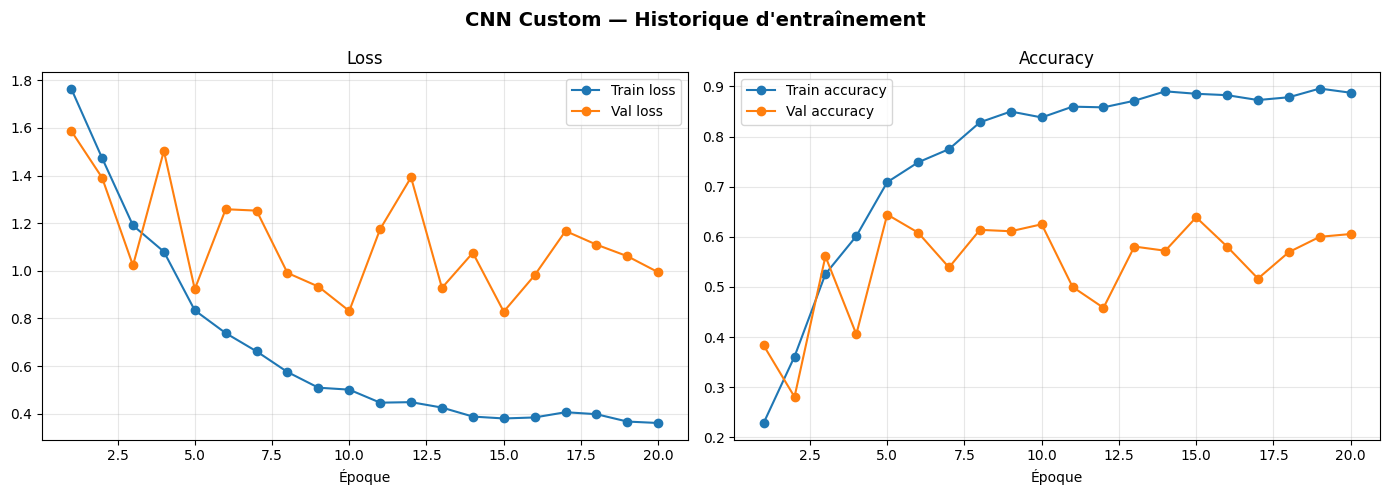

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN Custom — Historique d\'entraînement', fontsize=14, fontweight='bold')

epochs_range = range(1, len(history_cnn.history['loss']) + 1)

# Courbe Loss
ax1.plot(epochs_range, history_cnn.history['loss'],     label='Train loss',  marker='o')
ax1.plot(epochs_range, history_cnn.history['val_loss'], label='Val loss',    marker='o')
ax1.set_title('Loss')
ax1.set_xlabel('Époque')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Courbe Accuracy
ax2.plot(epochs_range, history_cnn.history['accuracy'],     label='Train accuracy', marker='o')
ax2.plot(epochs_range, history_cnn.history['val_accuracy'], label='Val accuracy',   marker='o')
ax2.set_title('Accuracy')
ax2.set_xlabel('Époque')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 6 — Approche B : Transfer Learning avec MobileNetV2

MobileNetV2 est pré-entraîné sur ImageNet (1.2M images, 1000 classes).

On gèle ses couches convolutives et on remplace uniquement sa tête
de classification par une adaptée à nos 6 classes.

**Avantage :** le modèle arrive déjà avec des features riches (bords,
textures, formes) — il n'a qu'à apprendre à les mapper sur nos défauts.

```
MobileNetV2 (154 couches gelées)
  └─ GlobalAveragePooling2D   : 7×7×1280 → 1280 valeurs
  └─ Dense(128) + ReLU
  └─ Dropout(0.3)
  └─ Dense(6)   + Softmax    
```

### Hyperparametres du Transfer Learning


In [14]:
# On utilise les memes hyperparametres que CNN pour une comparaison equitable
NB_EPOCHS_TL = 30
LR_TL        = 1e-4

### Construction du modèle

In [15]:
# Chargement de MobileNetV2 pré-entraîné
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False, # retire la tête de classification originale
    weights='imagenet' # conserve les poids appris sur ImageNet
)

# Gel de toutes les couches
# les poids de MobileNetV2 ne seront pas modifiés
# On exploite ses features sans risquer de les "désapprendre"
base_model.trainable = False

print(f"Couches totales dans MobileNetV2   : {len(base_model.layers)}")
print(f"Couches entraînables               : {len([l for l in base_model.layers if l.trainable])}")

# Construction de la nouvelle tête de classification
inputs = layers.Input(shape=(224, 224, 3))

# Passage dans MobileNetV2
x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x) # réduit 7×7×1280 → 1280 valeurs
# Beaucoup plus léger que Flatten (62 720 valeurs): moins d'overfitting

# Couche Dense intermédiaire
x = layers.Dense(128, activation='relu')(x)

# Dropout pour éviter l'overfitting sur les images
x = layers.Dropout(0.3)(x)

# Couche de sortie
outputs = layers.Dense(NB_CLASSES, activation='softmax')(x)

# Assemblage final
model_tl = models.Model(inputs, outputs)
model_tl.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Couches totales dans MobileNetV2   : 154
Couches entraînables               : 0


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Compilation du modèle


In [16]:
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_TL),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Modèle compilé et prêt à l'entraînement")

Modèle compilé et prêt à l'entraînement


### Entrainement du modèle

In [17]:
# Callbacks
callbacks_tl = [
    # Arrête si val_loss ne s'améliore plus pendant 5 époques
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    # Divise le LR par 2 si val_loss stagne pendant 3 époques
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    # Sauvegarde automatique du meilleur modèle
    ModelCheckpoint(
        filepath='best_tl_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
]

# Entraînement
print("Entraînement du Transfer Learning en cours...")

history_tl = model_tl.fit(
    train_generator,
    epochs=NB_EPOCHS_TL,
    validation_data=val_generator,
    callbacks=callbacks_tl,
    verbose=1
)

print("\nEntraînement terminé !")
print(f"Meilleure val_accuracy : {max(history_tl.history['val_accuracy']):.4f}")

Entraînement du Transfer Learning en cours...
Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.2537 - loss: 1.9915
Epoch 1: val_accuracy improved from None to 0.64444, saving model to best_tl_model.keras

Epoch 1: finished saving model to best_tl_model.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 52s 745ms/step - accuracy: 0.4403 - loss: 1.5411 - val_accuracy: 0.6444 - val_loss: 1.1002 - learning_rate: 1.0000e-04
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.7789 - loss: 0.8114
Epoch 2: val_accuracy improved from 0.64444 to 0.90000, saving model to best_tl_model.keras

Epoch 2: finished saving model to best_tl_model.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 401ms/step - accuracy: 0.8153 - loss: 0.7024 - val_accuracy: 0.9000 - val_loss: 0.6599 - learning_rate: 1.0000e-04
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.9008 - loss: 0.4313
Epoch 3: val_accuracy improved from 0.90000 to 0.93611, saving model to best_tl_model.keras

Epoch 3: finished sa

### Courbes d'entrainement — MobileNetV2 Transfer Learning


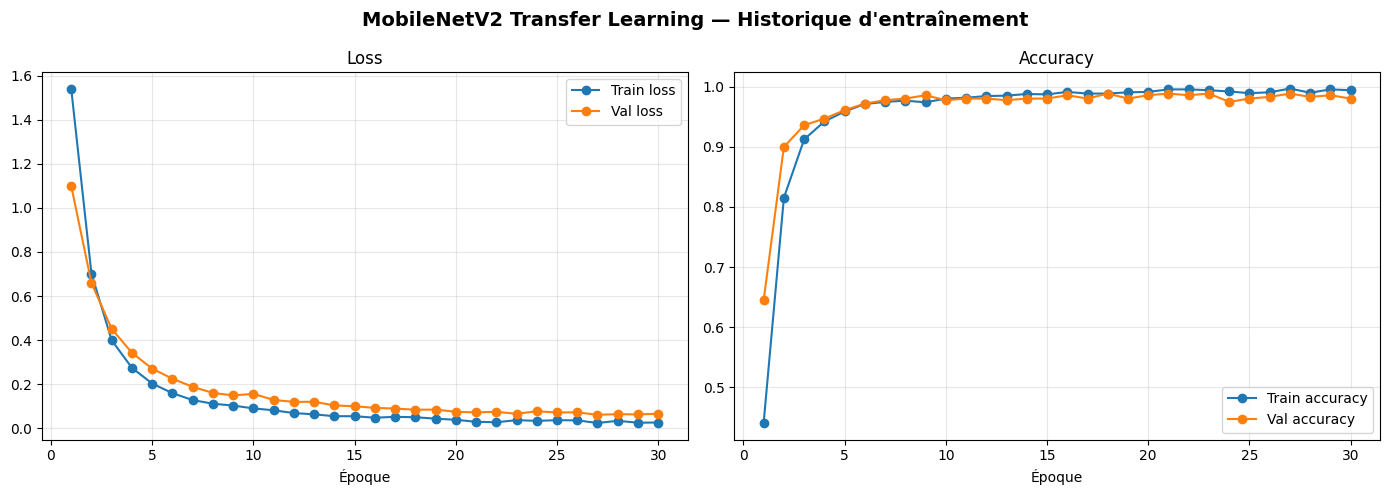

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MobileNetV2 Transfer Learning — Historique d'entraînement",
             fontsize=14, fontweight='bold')

epochs_range = range(1, len(history_tl.history['loss']) + 1)

ax1.plot(epochs_range, history_tl.history['loss'],     label='Train loss',     marker='o')
ax1.plot(epochs_range, history_tl.history['val_loss'], label='Val loss',       marker='o')
ax1.set_title('Loss')
ax1.set_xlabel('Époque')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history_tl.history['accuracy'],     label='Train accuracy', marker='o')
ax2.plot(epochs_range, history_tl.history['val_accuracy'], label='Val accuracy',   marker='o')
ax2.set_title('Accuracy')
ax2.set_xlabel('Époque')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()